# 03 - ML Segmentation (k-Means + Ward validation)

CRED Market Entry and Segmentation Diagnostic - Shashank Tiwari, IIT Kharagpur

In [1]:
import sys, warnings, logging
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import config
from src.utils import setup_logging
setup_logging(logging.INFO)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
FIG = config.FIGURES_DIR

In [2]:
from src.segmentation import run_kmeans, cluster_profiles, label_clusters, run_hierarchical, compute_jaccard
features = pd.read_csv(config.FEATURES_FILE)
clustered, km, X, sweep, sil = run_kmeans(features)
sweep.round(3)

04:52:35 | INFO    | cred.segmentation | k sweep complete - silhouette-optimal k = 6; using k = 6 (silhouette = 0.408)


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,433361.998,0.270,14547.474,1.735
1,3,336689.514,0.321,16142.944,1.252
2,4,255090.326,0.359,19240.483,1.107
3,5,204375.567,0.388,20940.835,0.988
4,6,167975.232,0.408,22429.504,0.954
5,7,155603.064,0.386,20802.859,1.030
6,8,145379.759,0.382,19558.968,1.093
7,9,136974.963,0.362,18526.091,1.143
8,10,129491.491,0.333,17722.200,1.282
9,11,126525.717,0.320,16434.197,1.206


## Choosing k
Inertia keeps falling with k (as it always does); the silhouette peaks at **k = 6**, matching the six designed archetypes.

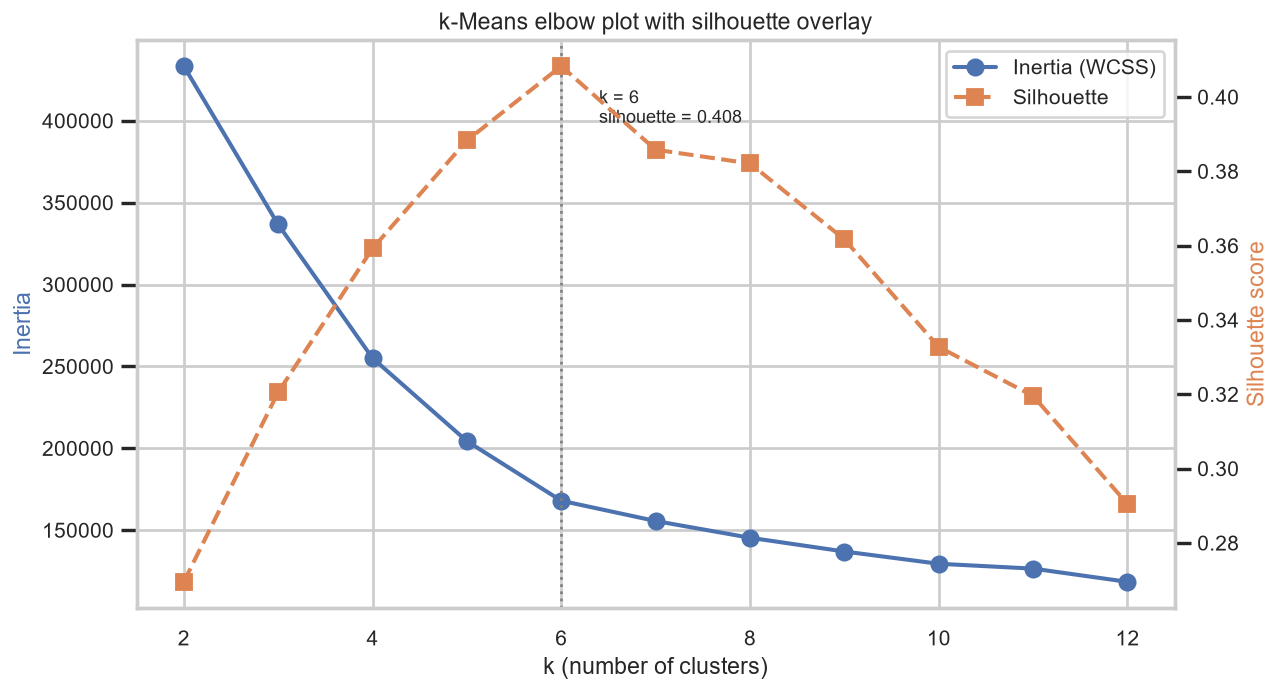

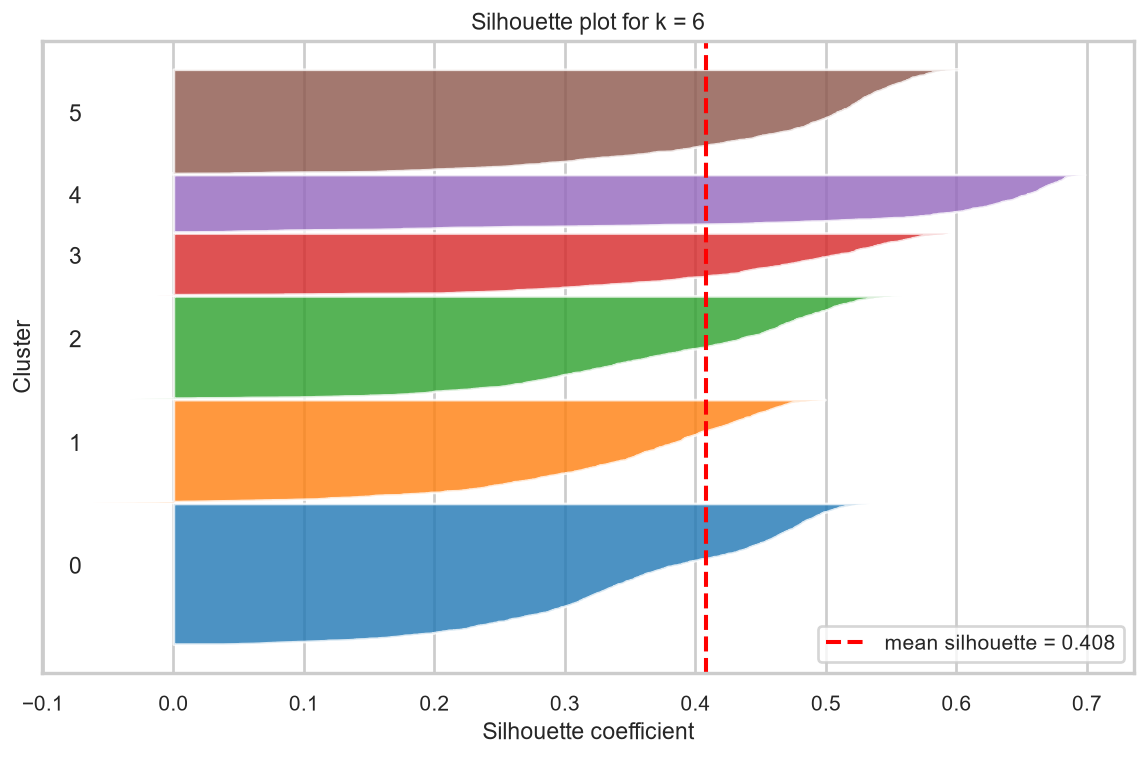

In [3]:
display(Image(FIG / 'elbow_plot.png', width=800)); display(Image(FIG / 'silhouette_k6.png', width=700))

In [4]:
names = label_clusters(clustered)
profiles = cluster_profiles(clustered)
profiles.insert(0, 'cluster_name', [names[c] for c in profiles.index])
profiles

,cluster_name,size,share_pct,scaled_to_market_M,total_card_limit,utilization_ratio,repayment_discipline,digital_savviness,card_diversity,premium_card_flag,emi_propensity,spend_volatility,income_to_limit_ratio,missed_payment_flag,upi_credit_adoption,reward_engagement,age,annual_income_lakhs,credit_score,num_cards,avg_monthly_spend
cluster,,,,,,,,,,,,,,,,,,,,,
0,Reward Chasers,11569,24.49,9.31,17.4469,0.0291,0.7802,0.7204,3.6976,0.3746,0.0746,0.2574,1.3326,0.0391,0.3242,0.8951,35.2794,19.9400,737.1857,5.9825,50714.8722
1,EMI-Dependent,8285,17.54,6.67,5.2840,0.0319,0.6019,0.5023,1.9229,0.0935,0.9780,0.2150,4.6381,0.2438,0.1838,0.2031,37.2435,16.9551,709.9482,2.2747,16879.5577
2,Digital-First,8602,18.21,6.92,6.3499,0.0210,0.7191,0.9332,2.1855,0.1172,0.0921,0.3249,3.9141,0.0806,0.8171,0.5038,28.7483,17.9187,723.8238,2.7011,13181.3477
3,Revolvers,5423,11.48,4.36,7.3169,0.0543,0.2267,0.5507,2.4564,0.1221,0.1158,0.3986,3.1450,0.9701,0.3967,0.2007,35.3592,15.8204,657.4005,3.1809,39560.8090
4,Conservative Savers,4693,9.94,3.78,3.2973,0.0125,0.9436,0.4332,1.1634,0.0823,0.0264,0.1895,7.7420,0.0194,0.0747,0.1309,42.7852,23.8067,755.2538,1.2063,4161.5157
5,Premium High-Spenders,8664,18.34,6.97,35.2421,0.0433,0.8984,0.7995,2.3128,0.9679,0.0437,0.2096,2.2284,0.0293,0.1250,0.3015,41.0758,54.6524,774.1256,2.9498,152332.1484


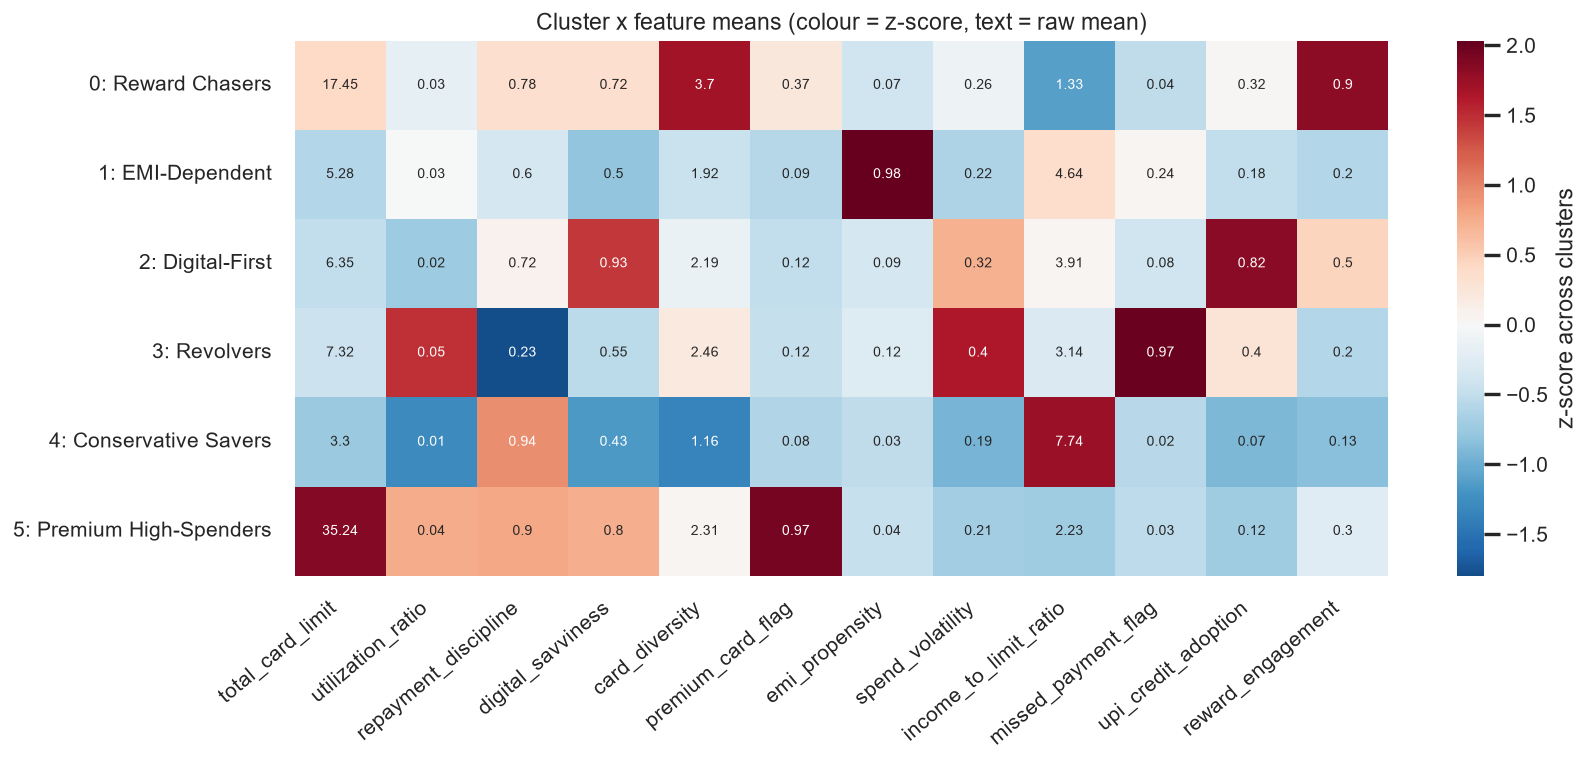

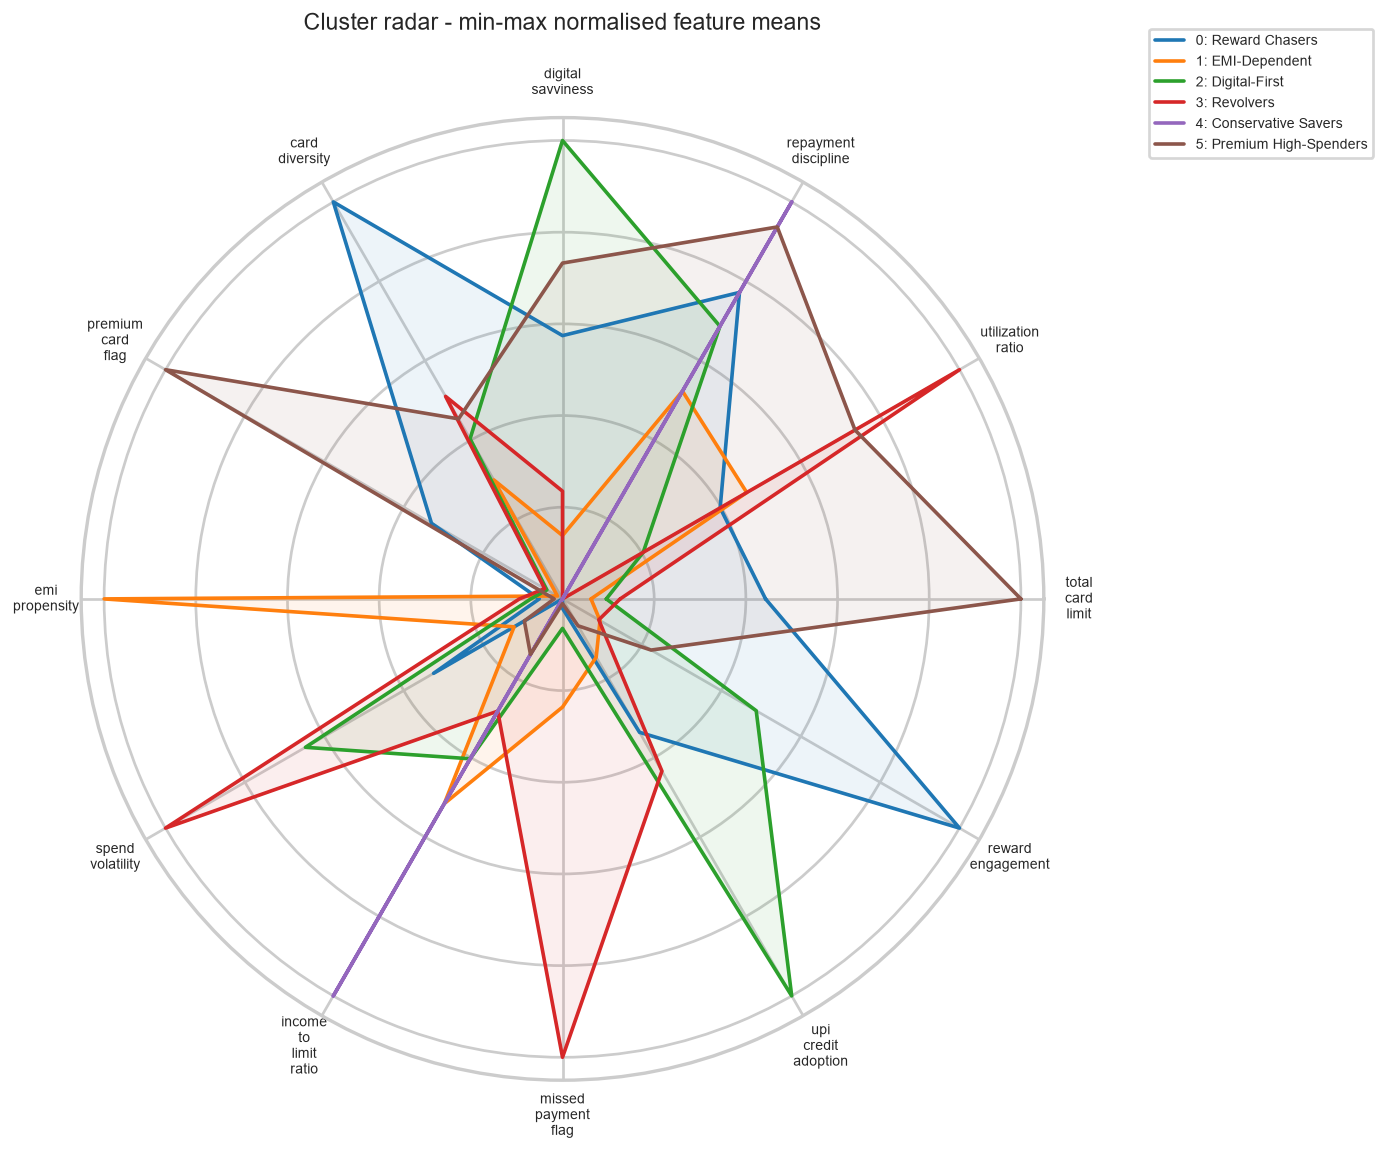

In [5]:
display(Image(FIG / 'cluster_heatmap.png', width=1000)); display(Image(FIG / 'cluster_radar.png', width=700))

## Hierarchical validation
Ward linkage on an 8,000-row sample, cut at k = 6, compared with k-Means via best-match Jaccard (Hungarian assignment).

In [6]:
idx, hl, Z = run_hierarchical(X)
jac, jmat, mapping = compute_jaccard(clustered['cluster'].to_numpy()[idx], hl)
print(f'weighted Jaccard = {jac:.3f}')
jmat

04:52:39 | INFO    | cred.segmentation | Ward hierarchical clustering on 8,000 rows -> 6 clusters


weighted Jaccard = 0.967


,hier_0,hier_1,hier_2,hier_3,hier_4,hier_5,best_match_jaccard
kmeans_0,0.0006,0.0000,0.9617,0.0000,0.0007,0.0000,0.9617
kmeans_1,0.0000,0.0021,0.0014,0.0004,0.0136,0.9701,0.9701
kmeans_2,0.9924,0.0000,0.0026,0.0000,0.0000,0.0000,0.9924
kmeans_3,0.0000,0.0000,0.0000,0.9957,0.0017,0.0000,0.9957
kmeans_4,0.0000,0.0082,0.0039,0.0000,0.9227,0.0000,0.9227
kmeans_5,0.0000,0.9498,0.0143,0.0000,0.0000,0.0004,0.9498


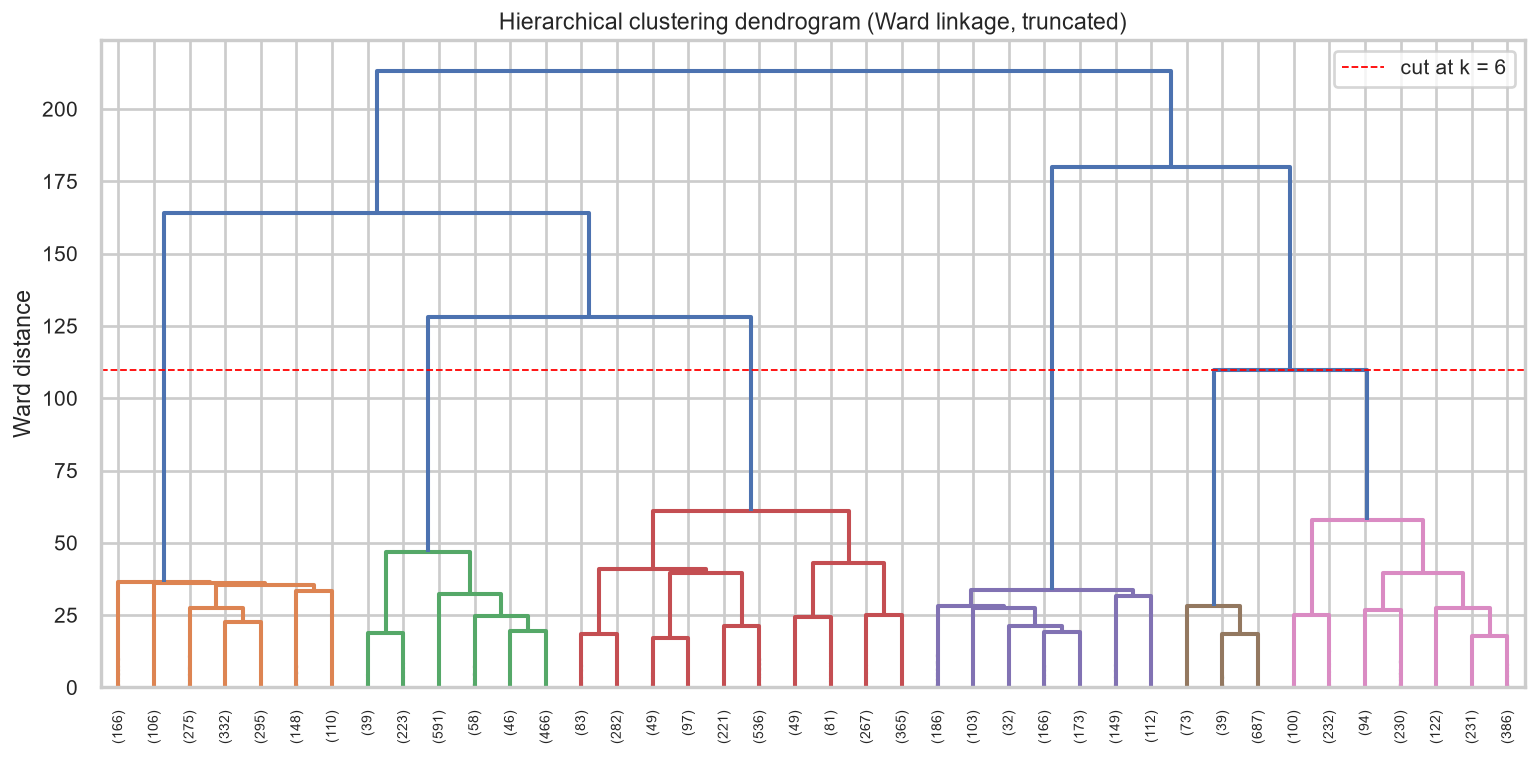

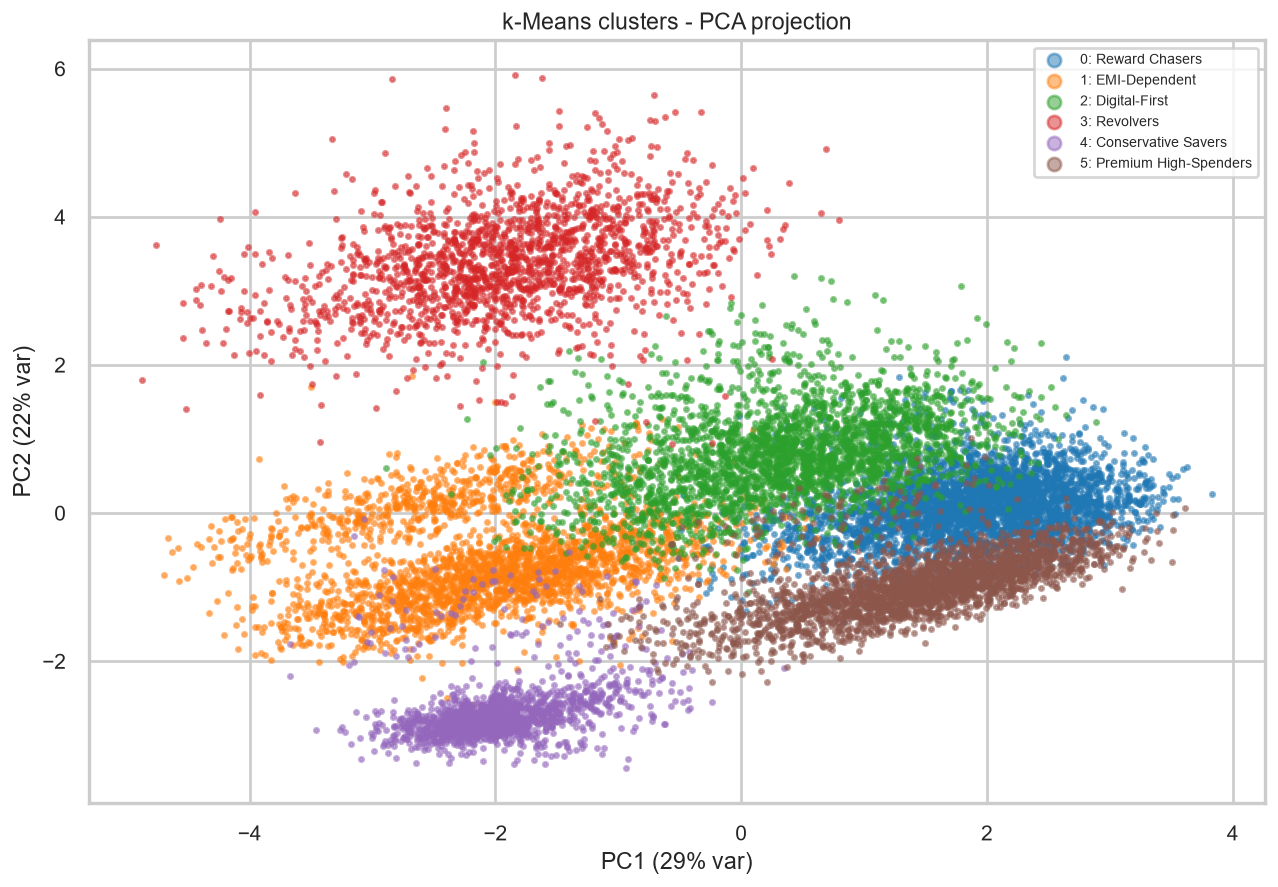

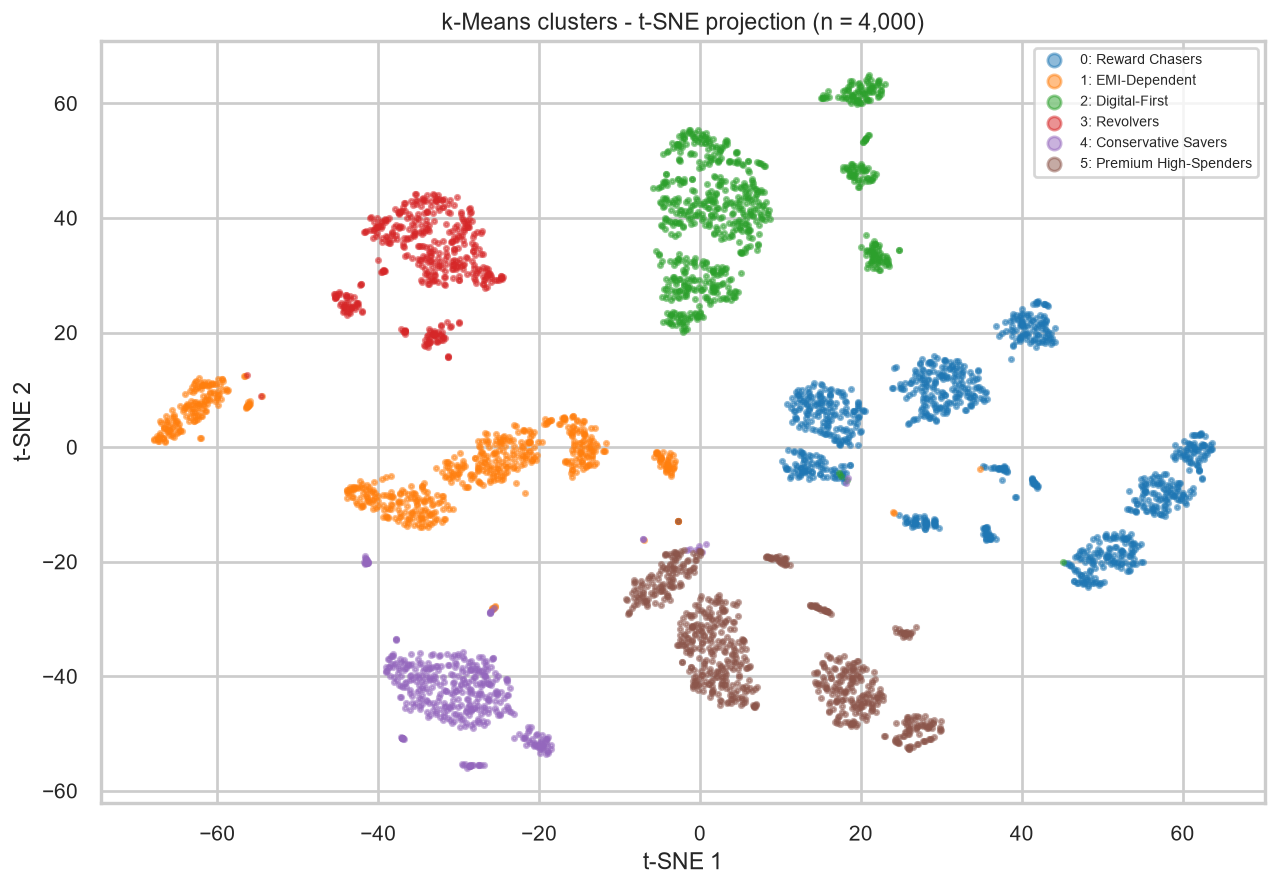

In [7]:
display(Image(FIG / 'dendrogram_ward.png', width=900)); display(Image(FIG / 'cluster_scatter_pca.png', width=700)); display(Image(FIG / 'cluster_scatter_tsne.png', width=700))

### Sanity check against the hidden archetypes
The latent archetype is never used for fitting - this crosstab only shows how well an unsupervised method recovers it.

In [8]:
pd.crosstab(clustered['cluster_name'] if 'cluster_name' in clustered else clustered['cluster'].map(names), clustered['latent_archetype'])

latent_archetype,Conservative Savers,Digital-First,EMI-Dependent,Premium High-Spenders,Revolvers,Reward Chasers
cluster,,,,,,
Conservative Savers,4452,0,98,118,0,25
Digital-First,0,8540,0,0,0,62
EMI-Dependent,8,0,8204,31,12,30
Premium High-Spenders,0,0,6,8652,0,6
Revolvers,0,0,6,0,5417,0
Reward Chasers,0,25,12,4,0,11528
